# Module 4 — Sampling, the Law of Large Numbers & the Central Limit Theorem

**Statistics Deep Dive · Notebook 4 of 13**

We almost never see the whole **population** — we see a **sample** and want to say something about the population. This module explains *why that works at all*, how much a sample statistic wobbles from sample to sample, and why the bell curve shows up everywhere. It is the bridge between probability (Modules 2–3) and inference (Modules 5+).

### 🎯 Learning goals
1. Distinguish **population / parameter** from **sample / statistic**.
2. Know the main **sampling designs** and the biases that ruin samples (selection, non-response, survivorship).
3. Understand a **sampling distribution** and the **standard error** $\sigma/\sqrt{n}$.
4. State and visualise the **law of large numbers (LLN)** and the **central limit theorem (CLT)** — and know when the CLT struggles.

### 🗺️ Contents
1. Population vs. sample · 2. Sampling designs · 3. Sampling bias · 4. Sampling distributions · 5. Standard error · 6. LLN · 7. CLT · 8. When the CLT struggles · 9. Other statistics · 10. Interactive explorer · 11. Exercises · 12. Takeaways

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

---
## 1. Population vs. sample — the fundamental picture

| | Population | Sample |
|---|---|---|
| What | *all* units of interest (all customers, all parts ever produced) | the $n$ units we actually observed |
| Numerical summary | **parameter**: $\mu,\ \sigma,\ p$ — fixed but **unknown** | **statistic**: $\bar x,\ s,\ \hat p$ — known but **random** (a different sample gives a different value) |
| Notation | Greek letters | Latin letters / hats |

**Inference** = using the statistic to make a calibrated statement about the parameter. It works only if the sample is drawn by a **known random mechanism**.

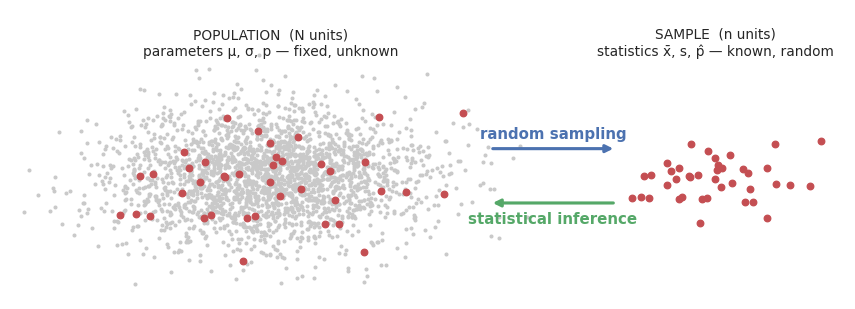

In [2]:
pop = rng.normal(0, 1, (2500, 2)) * [1.5, .9]; idx = rng.choice(len(pop), 40, replace=False)
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.scatter(*pop.T, s=5, color="#c9c9c9"); ax.scatter(*pop[idx].T, s=28, color=C[3], zorder=3)
ax.scatter(8.5 + pop[idx, 0] * .55, pop[idx, 1] * .55, s=28, color=C[3])
ax.annotate("", xy=(6.6, .7), xytext=(4.2, .7), arrowprops=dict(arrowstyle="-|>", lw=2.5, color=C[0])); ax.text(5.4, .95, "random sampling", ha="center", color=C[0], fontweight="bold")
ax.annotate("", xy=(4.2, -.7), xytext=(6.6, -.7), arrowprops=dict(arrowstyle="-|>", lw=2.5, color=C[2])); ax.text(5.4, -1.25, "statistical inference", ha="center", color=C[2], fontweight="bold")
ax.text(0, 3.1, "POPULATION  (N units)\nparameters μ, σ, p — fixed, unknown", ha="center", fontsize=11); ax.text(8.5, 3.1, "SAMPLE  (n units)\nstatistics x̄, s, p̂ — known, random", ha="center", fontsize=11)
ax.set(xlim=(-5, 11), ylim=(-3.2, 4.3)); ax.axis("off"); plt.show()

---
## 2. Sampling designs

| Design | How | Pros | Cons |
|---|---|---|---|
| **Simple random (SRS)** | every unit has the same chance | unbiased, simple theory | needs a full list; may miss small subgroups by chance |
| **Stratified** | split into homogeneous *strata*, SRS within each | guarantees representation, **smaller standard error** | need stratum info for every unit |
| **Cluster** | pick whole groups (schools, city blocks) at random | cheap field work | units within a cluster are similar → **larger** standard error |
| **Systematic** | every $k$-th unit from a random start | easy on production lines | fails if the list has a period of length $k$ |
| *Convenience* | whoever is easy to reach | cheap | **not a probability sample** — no valid inference |

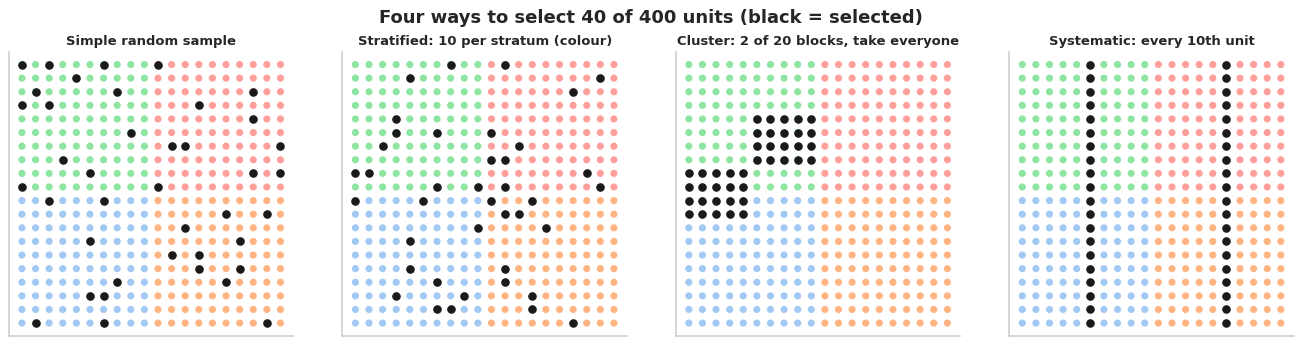

In [3]:
N = 20; xs, ys = [a.ravel() for a in np.meshgrid(np.arange(N), np.arange(N))]
strata, cluster = (xs >= 10) + 2 * (ys >= 10), xs // 5 + 4 * (ys // 4)
picks = {"Simple random sample": rng.choice(400, 40, replace=False),
         "Stratified: 10 per stratum (colour)": np.concatenate([rng.choice(np.where(strata == s)[0], 10, replace=False) for s in range(4)]),
         "Cluster: 2 of 20 blocks, take everyone": np.where(np.isin(cluster, rng.choice(20, 2, replace=False)))[0],
         "Systematic: every 10th unit": np.arange(rng.integers(10), 400, 10)}
fig, axes = plt.subplots(1, 4, figsize=(15, 3.9))
for ax, (name, p) in zip(axes, picks.items()):
    ax.scatter(xs, ys, c=[sns.color_palette("pastel")[s] for s in strata], s=22); ax.scatter(xs[p], ys[p], color="k", s=34, zorder=3)
    ax.set_title(name, fontsize=10.5); ax.set(xticks=[], yticks=[], aspect="equal")
fig.suptitle("Four ways to select 40 of 400 units (black = selected)", fontweight="bold"); plt.tight_layout(); plt.show()

---
## 3. Sampling bias — when more data does not help

A biased sampling mechanism gives a wrong answer **no matter how large $n$ is**. Famous examples:

* **Selection bias — Literary Digest, 1936.** 2.4 *million* responses predicted a landslide defeat for Roosevelt. The mailing list came from telephone directories and car registrations — i.e. wealthy people in the Great Depression. Roosevelt won 46 of 48 states. George Gallup got it right with 50,000 properly sampled people.
* **Non-response bias.** People who answer surveys differ from those who do not (Exercise 4.5).
* **Survivorship bias.** We only see what survived the selection process: WW2 engineers wanted to armour the bullet-riddled areas of *returning* bombers — Abraham Wald pointed out that the planes hit elsewhere never came back.

**Simulation — survivorship bias in fund performance.** 1000 funds with *identical* true skill (expected return 5 %, volatility 15 %). A fund is closed once it has lost more than 25 % of its starting value. A database listing only funds that still exist looks much better than the truth.

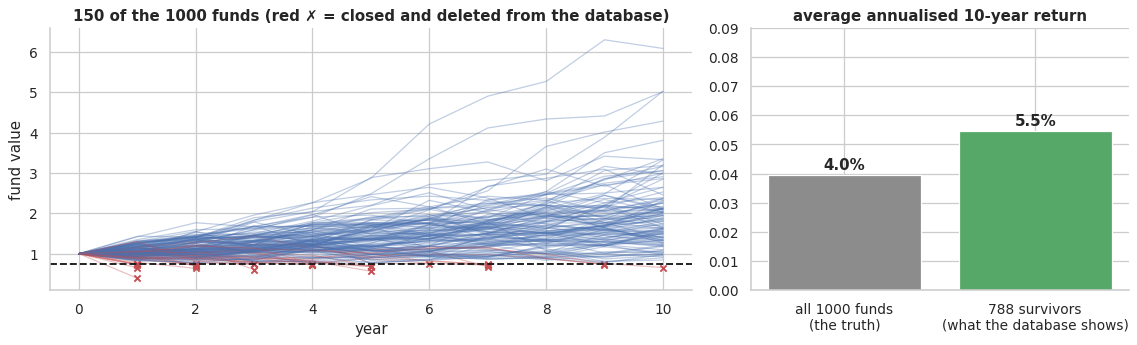

In [4]:
ret = rng.normal(.05, .15, (1000, 10)); value = np.cumprod(1 + ret, axis=1)
closed = (value < .75).any(axis=1); first_bad = np.where(closed, (value < .75).argmax(axis=1), 9)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [1.7, 1]})
for i in range(150):
    path = np.concatenate([[1], value[i, :first_bad[i] + 1]]); a1.plot(path, color=C[3] if closed[i] else C[0], alpha=.35, lw=1)
    if closed[i]: a1.scatter(len(path) - 1, path[-1], marker="x", color=C[3], s=25)
a1.axhline(.75, color="k", ls="--"); a1.set(xlabel="year", ylabel="fund value", title="150 of the 1000 funds (red ✗ = closed and deleted from the database)")
ann = lambda v: v[:, -1] ** (1 / 10) - 1
bars = {"all 1000 funds\n(the truth)": ann(value).mean(), f"{(~closed).sum()} survivors\n(what the database shows)": ann(value[~closed]).mean()}
a2.bar(list(bars), list(bars.values()), color=[C[7], C[2]]); [a2.text(i, v + .002, f"{v:.1%}", ha="center", fontweight="bold") for i, v in enumerate(bars.values())]
a2.set(title="average annualised 10-year return", ylim=(0, .09)); plt.tight_layout(); plt.show()

---
## 4. Sampling distributions — a statistic is a random variable

Draw a sample, compute $\bar x$. Draw another sample: a different $\bar x$. The distribution of a statistic over all possible samples is its **sampling distribution**. We normally observe only *one* sample — but in a simulation we can play the game thousands of times and *look* at the sampling distribution.

*Population:* 1 million household incomes (right-skewed, mean ≈ €45k). *Statistic:* the mean of a random sample of $n = 50$ households.

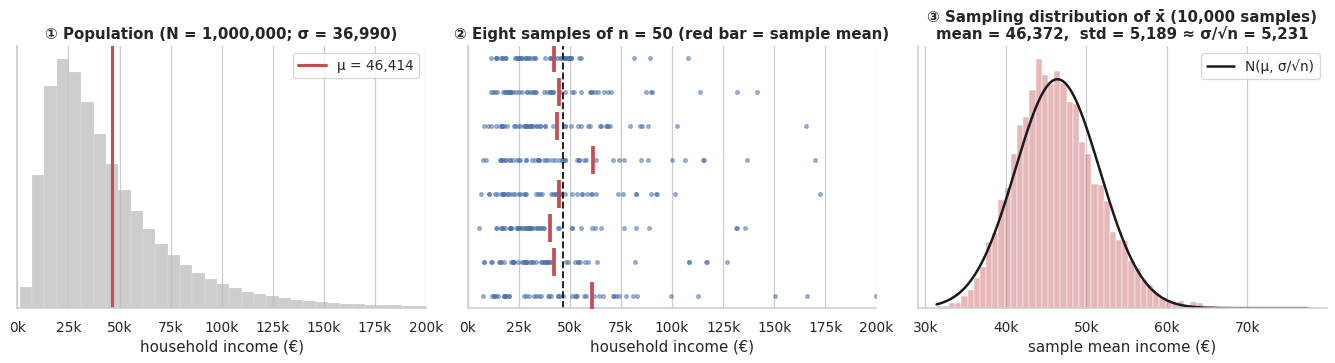

In [5]:
population = rng.lognormal(10.5, .7, 1_000_000); mu, sigma, n = population.mean(), population.std(), 50
means = rng.choice(population, (10_000, n)).mean(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
sns.histplot(population, bins=200, stat="density", ax=axes[0], color="#bdbdbd"); axes[0].axvline(mu, color=C[3], lw=2.5, label=f"μ = {mu:,.0f}")
axes[0].set(xlim=(0, 200_000), title=f"① Population (N = 1,000,000; σ = {sigma:,.0f})", yticks=[], ylabel=""); axes[0].legend()
for i in range(8):
    s = rng.choice(population, n); axes[1].scatter(s, np.full(n, i), s=9, color=C[0], alpha=.5); axes[1].scatter(s.mean(), i, marker="|", s=500, color=C[3], lw=3, zorder=3)
axes[1].axvline(mu, color="k", ls="--"); axes[1].set(xlim=(0, 200_000), yticks=[], title="② Eight samples of n = 50 (red bar = sample mean)")
sns.histplot(means, bins=60, stat="density", ax=axes[2], color=C[3], alpha=.4); xx = np.linspace(means.min(), means.max(), 300)
axes[2].plot(xx, stats.norm.pdf(xx, mu, sigma / np.sqrt(n)), color="k", lw=2, label="N(μ, σ/√n)")
axes[2].set(title=f"③ Sampling distribution of x̄ (10,000 samples)\nmean = {means.mean():,.0f},  std = {means.std():,.0f} ≈ σ/√n = {sigma / np.sqrt(n):,.0f}", yticks=[], ylabel=""); axes[2].legend()
for ax, lab in zip(axes, ["household income (€)", "household income (€)", "sample mean income (€)"]): ax.xaxis.set_major_formatter(lambda v, _: f"{v / 1000:.0f}k"); ax.set_xlabel(lab)
plt.tight_layout(); plt.show()

Three facts, visible in panel ③ and true for **any** population with finite variance:

1. $\mathbb{E}[\bar X] = \mu$ — the sample mean is **unbiased** (centred on the truth).
2. $\operatorname{SD}(\bar X) = \sigma/\sqrt{n}$ — the **standard error** (from "variances of independent variables add", Module 2).
3. The shape is approximately **normal**, although the population is heavily skewed — the central limit theorem.

---
## 5. The standard error — the price of precision

$$\text{SE}(\bar x) = \frac{\sigma}{\sqrt{n}} \approx \frac{s}{\sqrt{n}}$$

> **Standard deviation ≠ standard error.** SD describes how much *individual observations* vary — it does not shrink with more data. SE describes how much the *estimate* varies — it shrinks like $1/\sqrt n$. Because of the square root, **halving the error costs four times the data**; one more decimal digit costs 100×.

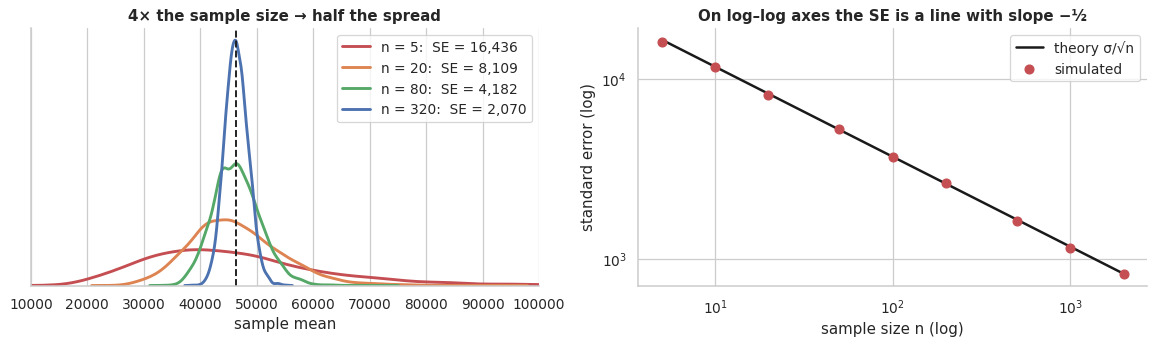

In [6]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
ns = [5, 20, 80, 320]
for n_i, col in zip(ns, [C[3], C[1], C[2], C[0]]):
    m = rng.choice(population, (5000, n_i)).mean(axis=1); sns.kdeplot(m, ax=a1, color=col, lw=2.3, label=f"n = {n_i}:  SE = {m.std():,.0f}")
a1.axvline(mu, color="k", ls="--"); a1.set(xlim=(10_000, 100_000), yticks=[], ylabel="", xlabel="sample mean", title="4× the sample size → half the spread"); a1.legend()
grid = np.array([5, 10, 20, 50, 100, 200, 500, 1000, 2000]); sim = [rng.choice(population, (3000, k)).mean(axis=1).std() for k in grid]
a2.loglog(grid, sigma / np.sqrt(grid), color="k", lw=2, label="theory σ/√n"); a2.scatter(grid, sim, color=C[3], zorder=3, s=50, label="simulated")
a2.set(xlabel="sample size n (log)", ylabel="standard error (log)", title="On log–log axes the SE is a line with slope −½"); a2.legend(); plt.tight_layout(); plt.show()

---
## 6. The law of large numbers (LLN)

$$\bar X_n \xrightarrow{\;n\to\infty\;} \mu$$

The sample mean converges to the population mean. The LLN says *where* $\bar X$ goes; the standard error says *how fast* (the funnel $\mu \pm 2\sigma/\sqrt n$ below).

> ⚠️ The LLN does **not** say that deviations are "compensated" (gambler's fallacy). After 10 heads in a row the coin owes you nothing; the early excess is simply *diluted* by the many flips that follow.

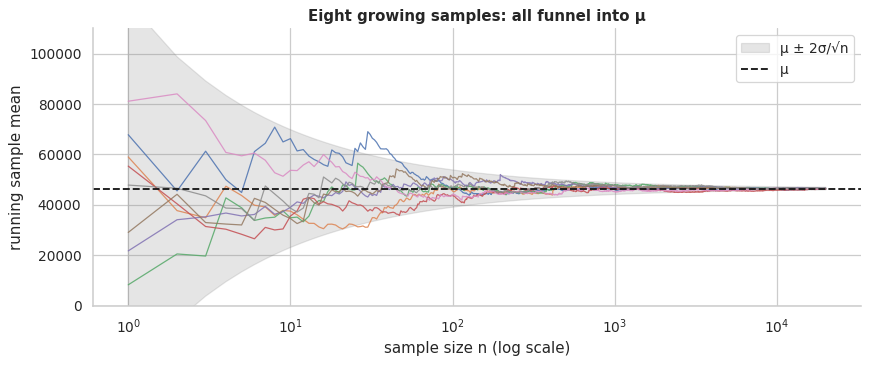

In [7]:
n_max = 20_000; k = np.arange(1, n_max + 1); fig, ax = plt.subplots(figsize=(11, 4))
for _ in range(8): ax.plot(k, rng.choice(population, n_max).cumsum() / k, lw=1, alpha=.85)
ax.fill_between(k, mu - 2 * sigma / np.sqrt(k), mu + 2 * sigma / np.sqrt(k), color="grey", alpha=.2, label="μ ± 2σ/√n")
ax.axhline(mu, color="k", ls="--", label="μ"); ax.set(xscale="log", ylim=(0, 110_000), xlabel="sample size n (log scale)", ylabel="running sample mean", title="Eight growing samples: all funnel into μ"); ax.legend(); plt.show()

---
## 7. The central limit theorem (CLT)

> For independent observations from **any** distribution with mean $\mu$ and finite variance $\sigma^2$, the standardised sample mean converges to a standard normal:
> $$\frac{\bar X_n - \mu}{\sigma/\sqrt n} \;\longrightarrow\; N(0,1)$$

This is why the normal distribution is everywhere: anything that is a *sum or average of many small, independent contributions* is approximately normal — *regardless of how each contribution is distributed*. It is also the licence behind z- and t-procedures for non-normal data.

**How large must $n$ be?** It depends on the parent's skewness and tail weight — look at the rows below. The red curve is the normal approximation.

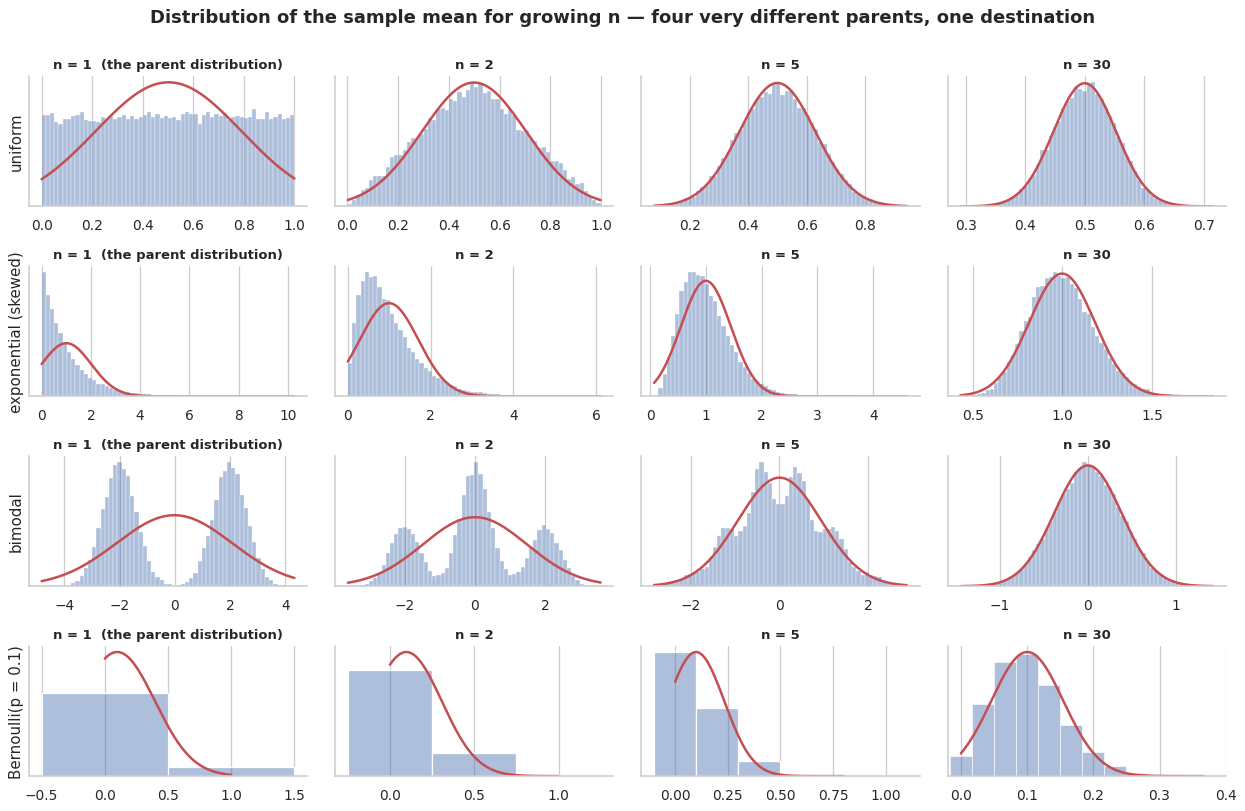

In [8]:
parents = {"uniform": lambda s: rng.uniform(0, 1, s), "exponential (skewed)": lambda s: rng.exponential(1, s),
           "bimodal": lambda s: np.where(rng.random(s) < .5, rng.normal(-2, .6, s), rng.normal(2, .6, s)),
           "Bernoulli(p = 0.1)": lambda s: (rng.random(s) < .1).astype(float)}
ns = [1, 2, 5, 30]; fig, axes = plt.subplots(4, 4, figsize=(14, 9))
for i, (name, draw) in enumerate(parents.items()):
    for j, n_j in enumerate(ns):
        m = draw((30_000, n_j)).mean(axis=1); ax = axes[i, j]
        bins = np.linspace(-.5 / n_j, 1 + .5 / n_j, n_j + 2) if "Bern" in name else 60
        sns.histplot(m, bins=bins, stat="density", ax=ax, color=C[0], alpha=.45)
        xx = np.linspace(m.min(), m.max(), 300); ax.plot(xx, stats.norm.pdf(xx, m.mean(), m.std()), color=C[3], lw=2)
        if "Bern" in name and n_j == 30: ax.set_xlim(-.02, .4)
        ax.set(yticks=[], ylabel=name if j == 0 else ""); ax.set_title(f"n = {n_j}" + ("  (the parent distribution)" if n_j == 1 else ""), fontsize=10.5)
fig.suptitle("Distribution of the sample mean for growing n — four very different parents, one destination", fontweight="bold", y=1.0); plt.tight_layout(); plt.show()

**Reading the gallery.** The symmetric uniform is bell-shaped from $n \approx 5$. The skewed exponential still shows a right tail at $n = 5$ and is decent at $n = 30$. The rare-event Bernoulli is still visibly skewed and lumpy at $n = 30$ ($np = 3$) — this is where the rule "$np \ge 10$" for proportions comes from. *"n ≥ 30" is folklore, not a theorem.*

---
## 8. When the CLT struggles — heavy tails

The CLT needs a **finite variance**. The **Cauchy** distribution (e.g. the ratio of two normals) has no mean and no variance: the average of a million Cauchy values is exactly as erratic as a single one. For finite-variance but very skewed data (lognormal with large σ, Pareto-like losses) the CLT holds in theory but convergence is painfully slow: the skewness of $\bar X$ only decays like $\text{skew}/\sqrt{n}$.

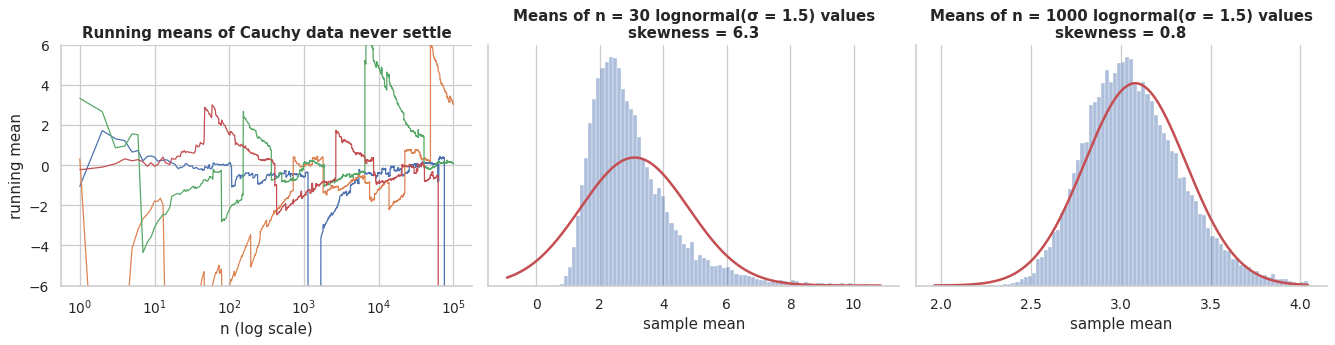

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4)); k = np.arange(1, 100_001)
for _ in range(4):
    axes[0].plot(k, rng.standard_cauchy(100_000).cumsum() / k, lw=1)
axes[0].set(xscale="log", ylim=(-6, 6), title="Running means of Cauchy data never settle", xlabel="n (log scale)", ylabel="running mean")
for ax, n_k in zip(axes[1:], [30, 1000]):
    m = rng.lognormal(0, 1.5, (20_000, n_k)).mean(axis=1); lo, hi = np.quantile(m, [0, .995]); sns.histplot(m, bins=80, stat="density", ax=ax, color=C[0], alpha=.45, binrange=(lo, hi))
    xx = np.linspace(lo - .15 * (hi - lo), hi, 300); ax.plot(xx, stats.norm.pdf(xx, m.mean(), m.std()), color=C[3], lw=2)
    ax.set(yticks=[], ylabel="", xlabel="sample mean", title=f"Means of n = {n_k} lognormal(σ = 1.5) values\nskewness = {stats.skew(m):.1f}")
plt.tight_layout(); plt.show()

Even with $n = 1000$ the sampling distribution of the mean is still clearly right-skewed. For such data use the **median**, a **log transformation**, or the **bootstrap** (Module 5) instead of normal-theory formulas.

---
## 9. Other statistics have sampling distributions too

* **Sample proportion:** $\hat p$ is a mean of 0/1 values ⇒ $\text{SE}(\hat p) = \sqrt{p(1-p)/n}$, approximately normal when $np$ and $n(1-p)$ are both ≳ 10.
* **Sample median:** approximately normal with $\text{SE} \approx 1.25\,\sigma/\sqrt n$ for normal data — 25 % *less* precise than the mean, the price of robustness. For heavy-tailed data the ranking flips.
* **Sample standard deviation:** right-skewed for small $n$ (its square follows a scaled $\chi^2_{n-1}$ for normal data).

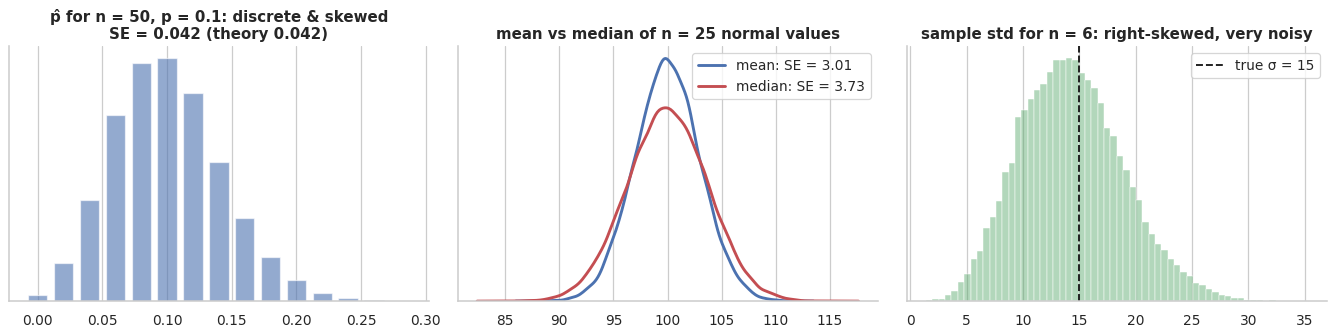

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.9))
ph = rng.binomial(50, .1, 50_000) / 50; axes[0].bar(*np.unique(ph, return_counts=True), width=.015, color=C[0], alpha=.6)
axes[0].set(title=f"p̂ for n = 50, p = 0.1: discrete & skewed\nSE = {ph.std():.3f} (theory {np.sqrt(.1 * .9 / 50):.3f})", yticks=[])
x = rng.normal(100, 15, (30_000, 25)); 
for stat, name, col in [(x.mean(axis=1), "mean", C[0]), (np.median(x, axis=1), "median", C[3])]: sns.kdeplot(stat, ax=axes[1], color=col, lw=2.3, label=f"{name}: SE = {stat.std():.2f}")
axes[1].set(title="mean vs median of n = 25 normal values", yticks=[], ylabel=""); axes[1].legend()
s = rng.normal(100, 15, (30_000, 6)).std(axis=1, ddof=1); sns.histplot(s, bins=60, stat="density", ax=axes[2], color=C[2], alpha=.45); axes[2].axvline(15, color="k", ls="--", label="true σ = 15")
axes[2].set(title="sample std for n = 6: right-skewed, very noisy", yticks=[], ylabel=""); axes[2].legend(); plt.tight_layout(); plt.show()

---
## 10. 🎛️ Interactive CLT explorer
With `ipywidgets` installed you get a drop-down and a slider; otherwise a static example is shown.

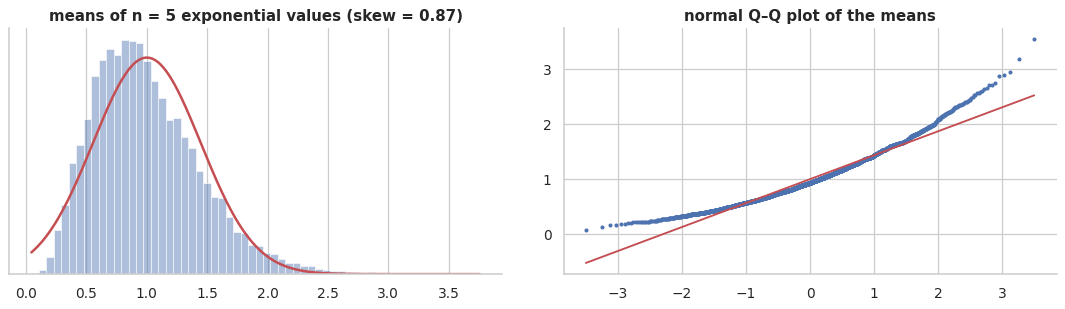

In [11]:
def explore_clt(parent="exponential", n=5):
    draw = {"exponential": lambda s: rng.exponential(1, s), "uniform": lambda s: rng.uniform(0, 1, s),
            "lognormal": lambda s: rng.lognormal(0, 1, s), "dice": lambda s: rng.integers(1, 7, s).astype(float)}[parent]
    m = draw((20_000, n)).mean(axis=1); fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.6))
    sns.histplot(m, bins=60, stat="density", ax=a1, color=C[0], alpha=.45); xx = np.linspace(m.min(), m.max(), 300)
    a1.plot(xx, stats.norm.pdf(xx, m.mean(), m.std()), color=C[3], lw=2); a1.set(title=f"means of n = {n} {parent} values (skew = {stats.skew(m):.2f})", yticks=[], ylabel="")
    (osm, osr), (sl, ic, _) = stats.probplot(m[:3000]); a2.scatter(osm, osr, s=5, color=C[0]); a2.plot(osm, ic + sl * osm, color=C[3]); a2.set(title="normal Q–Q plot of the means")
    plt.tight_layout(); plt.show()

try:
    from ipywidgets import interact
    interact(explore_clt, parent=["exponential", "uniform", "lognormal", "dice"], n=(1, 200, 1))
except ImportError:
    explore_clt()

---
## 11. Exercises — real-world use cases

### ✍️ Exercise 4.1 — *Standard error of a proportion*: How many people must a pollster ask? (Opinion research)

A polling institute wants to estimate the vote share $p$ of a party (true value around 30 %) in a country with 60 million voters.

**Tasks**
1. For an SRS, compute the 95 % **margin of error** $1.96\sqrt{p(1-p)/n}$ for $n$ = 100, 500, 1000, 2000, 10,000. Plot margin of error against $n$.
2. How many respondents are needed for ±2 points? For ±1 point?
3. Simulate 10,000 polls with $n = 1000$ and true $p = 0.30$. How often is a poll off by more than 3 points? Compare the simulated SE with the formula.
4. The same institute polls Luxembourg (≈ 300,000 voters). Does it need a smaller sample? Use the finite-population correction $\sqrt{(N-n)/(N-1)}$ to justify your answer.

In [12]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/04_sampling_lln_clt_solutions.ipynb`.

### ✍️ Exercise 4.2 — *Sampling designs*: Auditing inventory with 100 store visits (Retail audit)

A retail chain has 2,000 stores in three formats. Auditors can physically count inventory in only **100 stores** and want to estimate the **mean inventory value per store**.

**Tasks**
1. Compare three designs by simulating 5,000 audits each: (a) SRS of 100 stores, (b) stratified with *proportional* allocation, (c) stratified with *Neyman* allocation $n_h \propto N_h\sigma_h$ (use the stratum standard deviations from `stores`).
2. Plot the three sampling distributions of the estimated mean. Are all designs unbiased? Report the standard errors.
3. How many stores would an SRS need to match the precision of design (c)?

In [13]:
g = np.random.default_rng(402)
fmt = np.repeat(["hypermarket", "supermarket", "convenience"], [100, 600, 1300])
value = np.concatenate([g.normal(900, 150, 100), g.normal(300, 60, 600), g.normal(60, 20, 1300)]).clip(5)   # k€
stores = pd.DataFrame({"format": fmt, "inventory_keur": value.round(1)})
stores.groupby("format").inventory_keur.agg(["count", "mean", "std"]).round(1)

,count,mean,std
format,,,
convenience,1300,59.1,20.1
hypermarket,100,911.8,168.1
supermarket,600,302.7,59.7


In [14]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/04_sampling_lln_clt_solutions.ipynb`.

### ✍️ Exercise 4.3 — *Sampling distribution of the mean*: Monitoring a bottling line (Statistical process control)

A filling machine is set to **502 ml** with σ = 4 ml (individual bottles, normally distributed). Every hour QA takes **n = 25** bottles and records the mean. The label says 500 ml.

**Tasks**
1. What is the probability that a *single* bottle contains less than 500 ml? That the *mean of 25* is below 500 ml? Plot both distributions in one figure.
2. Compute the 3-sigma **control limits** for the hourly mean $\bar x$. What is the false-alarm probability per hour when the process is fine?
3. The array `hourly` holds 60 hours × 25 bottles. Draw the $\bar x$ control chart. When does the chart signal, and what probably happened?
4. After the shift, what is the probability per hour that the chart detects it?

In [15]:
g = np.random.default_rng(403)
hourly = g.normal(502, 4, (60, 25)); hourly[38:] -= 2.2          # something happens after hour 38 ...
hourly = hourly.round(1); hourly.shape

(60, 25)

In [16]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/04_sampling_lln_clt_solutions.ipynb`.

### ✍️ Exercise 4.4 — *CLT in practice*: Can we trust normal-theory alerts on skewed latency? (Site reliability engineering)

An API has lognormal latencies (median ≈ 100 ms, heavy right tail). The monitoring system averages the latency of $n$ requests and raises an alert when the average exceeds $\mu + 3\,\sigma/\sqrt n$ — which "should" happen with probability 0.00135 if the average were normal.

**Tasks**
1. For $n$ = 5, 30, 200, 2000 simulate 100,000 averages. Plot their distributions with the normal approximation.
2. For each $n$ report the skewness of the averages and the **actual** false-alarm rate. By what factor is it off?
3. Propose two ways to obtain alerts with a reliable false-alarm rate.

In [17]:
lat = stats.lognorm(s=0.9, scale=100)                     # latency distribution in ms
print(f"median = {lat.median():.0f} ms, mean = {lat.mean():.0f} ms, sd = {lat.std():.0f} ms, skewness = {float(lat.stats('s')):.1f}")

median = 100 ms, mean = 150 ms, sd = 167 ms, skewness = 4.7


In [18]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/04_sampling_lln_clt_solutions.ipynb`.

### ✍️ Exercise 4.5 — *Sampling bias*: A satisfaction survey with 9,000 answers — and the wrong result (Customer insights)

A streaming service e-mails a satisfaction survey (score 1–10) to all 50,000 customers. 9,000 respond. The CRM system knows each customer's **age segment**, and (in this simulated world) we also know everyone's true score.

**Tasks**
1. Compare the true mean satisfaction with the mean of the respondents. How large is the bias compared with the (naive) standard error?
2. Would 20,000 responses help? Explain using "bias vs. standard error".
3. Compare the segment mix among respondents with the customer base, then compute a **post-stratified** estimate (weight each segment's mean by its population share).
4. Under which circumstances would weighting *not* fix the problem?

In [19]:
g = np.random.default_rng(405); Ncust = 50_000
segment = g.choice(["18–34", "35–54", "55+"], Ncust, p=[.45, .35, .20])
score = np.clip(np.round(g.normal(pd.Series(segment).map({"18–34": 6.0, "35–54": 7.2, "55+": 8.4}), 1.6)), 1, 10)
responded = g.random(Ncust) < pd.Series(segment).map({"18–34": .07, "35–54": .18, "55+": .45}).to_numpy()
customers = pd.DataFrame({"segment": segment, "score": score, "responded": responded})
print(f"{responded.sum():,} of {Ncust:,} customers responded"); customers.head()

9,197 of 50,000 customers responded


,segment,score,responded
0,55+,9.0,False
1,18–34,6.0,False
2,35–54,10.0,False
3,55+,8.0,False
4,35–54,6.0,False


In [20]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/04_sampling_lln_clt_solutions.ipynb`.

---
## 12. 🔑 Key takeaways

* A **statistic** is a random variable; its distribution over repeated samples is the **sampling distribution**.
* $\bar X$ is unbiased with **standard error $\sigma/\sqrt n$**: 4× data → ½ error. SD describes data, SE describes estimates.
* **LLN:** $\bar X \to \mu$ (by dilution, not compensation). **CLT:** sums/averages become normal whatever the parent — *if* the variance is finite; heavy skew and heavy tails need far more than "n = 30".
* Random sampling makes inference possible; **stratification** makes it cheaper; **bias** makes it impossible, and no sample size can repair it.
* Precision depends on $n$, hardly on the population size $N$.

**Next:** Module 5 — turning these ideas into estimators, maximum likelihood, confidence intervals and the bootstrap.